# Sprint 1: Análisis Exploratorio de Datos (EDA) - Churn Olist
### Enfoque: Paso a Paso para la toma de decisiones de negocio
**Contexto:** En un modelo no contractual (e-commerce), el Churn se define por inactividad. Este Notebook demuestra de forma transparente cómo limpiar el ruido de los datos para justificar estadísticamente el umbral de Churn.

## Maestrantes
Percy Fuentes

Nelson de la Quintana

Paolo Ramos

## 🛠️ PASO 1: Configuración del Entorno Estético

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Estética corporativa/profesional
sns.set_theme(style="whitegrid", palette="dark")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

PATH = 'dataset/'
print("✅ Entorno listo y estética configurada.")

✅ Entorno listo y estética configurada.


## 📋 PASO 2: Carga y Diagnóstico Técnico (Auditoría Inicial)
Aquí identificamos las dimensiones originales y evaluamos dónde está el ruido.

In [2]:
# Carga de las 4 tablas esenciales
orders = pd.read_csv(os.path.join(PATH, 'olist_orders_dataset.csv'))
customers = pd.read_csv(os.path.join(PATH, 'olist_customers_dataset.csv'))
payments = pd.read_csv(os.path.join(PATH, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(PATH, 'olist_order_reviews_dataset.csv'))

print(f"🔹 [Original] Orders:    {orders.shape}")
print(f"🔹 [Original] Customers: {customers.shape}")
print(f"🔹 [Original] Payments:  {payments.shape}")
print(f"🔹 [Original] Reviews:   {reviews.shape}")

🔹 [Original] Orders:    (99441, 8)
🔹 [Original] Customers: (99441, 5)
🔹 [Original] Payments:  (103886, 5)
🔹 [Original] Reviews:   (99224, 7)


## 🧼 PASO 3: Mitigación de Ruido (Limpieza de Datos Críticos)
Para evitar sesgos y duplicados artificiales, aplicamos tres reglas de negocio:
1. **Filtrado por Estatus:** Solo órdenes `delivered` (entregadas).
2. **Consolidación de Pagos:** Agrupar `payment_value` por `order_id` para resolver la relación 1-a-muchos.
3. **Tipado de Fechas:** Transformar cadenas de texto a `datetime`.

### Diccionario de Datos: Olist E-commerce

#### 1. Tabla de Órdenes (`olist_orders_dataset`)
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `order_id` | Identificador | ID único de la transacción |
| `customer_id` | Identificador | ID de cliente por pedido |
| `order_status` | Categórico | Estado del pedido |
| `order_purchase_timestamp` | Temporal | Fecha/Hora de compra |
| `order_approved_at` | Temporal | Fecha/Hora aprobación pago |
| `order_delivered_customer_date`| Temporal | Fecha de entrega real |
| `order_estimated_delivery_date`| Temporal | Fecha de entrega estimada |

#### 2. Tabla de Clientes (`olist_customers_dataset`)
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `customer_id` | Identificador | Clave única por pedido |
| `customer_unique_id` | Identificador | Clave única del usuario (persona) |
| `customer_zip_code_prefix` | Discreto | Prefijo del código postal |
| `customer_city` | Categórico | Ciudad del cliente |
| `customer_state` | Categórico | Estado (UF) del cliente |

#### 3. Tabla de Pagos (`olist_order_payments_dataset`)
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `order_id` | Identificador | ID único de la transacción |
| `payment_sequential` | Discreto | Número de secuencia del pago |
| `payment_type` | Categórico | Método de pago (credit_card, etc.) |
| `payment_installments`| Discreto | Número de cuotas |
| `payment_value` | Continuo | Valor monetario del pago |

#### 4. Tabla de Reseñas (`olist_order_reviews_dataset`)
| Columna | Tipo | Descripción |
| :--- | :--- | :--- |
| `review_id` | Identificador | ID único de la reseña |
| `order_id` | Identificador | ID de la orden asociada |
| `review_score` | Discreto | Puntaje (1-5 estrellas) |
| `review_comment_title` | Texto | Título del comentario |
| `review_comment_message`| Texto | Mensaje del cliente |
| `review_creation_date` | Temporal | Fecha de creación de la reseña |
| `review_answer_timestamp`| Temporal | Fecha de respuesta a la reseña |

In [4]:
# --- LOG DE LIMPIEZA: ÓRDENES ---
initial_orders = len(orders)
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
final_orders = len(orders_clean)

print("📝 LOG DE LIMPIEZA - ÓRDENES")
print(f"Total órdenes iniciales: {initial_orders}")
print(f"Órdenes filtradas (No 'delivered'): {initial_orders - final_orders}")
print(f"Órdenes finales para análisis: {final_orders} ({final_orders/initial_orders:.1%})")
print("-" * 40)

# --- LOG DE LIMPIEZA: PAGOS ---
initial_payments = len(payments)
payments_grouped = payments.groupby('order_id')['payment_value'].sum().reset_index()
final_payments = len(payments_grouped)

print("📝 LOG DE LIMPIEZA - PAGOS")
print(f"Registros de pagos iniciales: {initial_payments}")
print(f"Registros consolidados (por order_id): {final_payments}")
print(f"Duplicados/Cuotas eliminados: {initial_payments - final_payments}")
print("-" * 40)

# 2. Convertir fechas
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
orders_clean['order_delivered_customer_date'] = pd.to_datetime(orders_clean['order_delivered_customer_date'])
orders_clean['order_estimated_delivery_date'] = pd.to_datetime(orders_clean['order_estimated_delivery_date'])

# 4. Construcción de la Master Table Única
df_master = pd.merge(orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']], 
                     customers[['customer_id', 'customer_unique_id']], 
                     on='customer_id')

df_master = pd.merge(df_master, payments_grouped, on='order_id', how='left')

print(f"✅ MASTER TABLE GENERADA")
print(f"Transacciones únicas finales: {df_master.shape[0]}")
print(f"Clientes únicos reales: {df_master['customer_unique_id'].nunique()}")
print(f"Nulos en pagos tras el merge: {df_master['payment_value'].isnull().sum()}")

📝 LOG DE LIMPIEZA - ÓRDENES
Total órdenes iniciales: 99441
Órdenes filtradas (No 'delivered'): 2963
Órdenes finales para análisis: 96478 (97.0%)
----------------------------------------
📝 LOG DE LIMPIEZA - PAGOS
Registros de pagos iniciales: 103886
Registros consolidados (por order_id): 99440
Duplicados/Cuotas eliminados: 4446
----------------------------------------
✅ MASTER TABLE GENERADA
Transacciones únicas finales: 96478
Clientes únicos reales: 93358
Nulos en pagos tras el merge: 1


## 🔄 PASO 4: Análisis de Recurrencia (Justificación del Modelo)
Evaluamos la frecuencia de compra para justificar que el e-commerce es principalmente transaccional.

In [5]:
# Calcular compras por cliente único
compras_por_cliente = df_master.groupby('customer_unique_id')['order_id'].count().reset_index()
compras_por_cliente.columns = ['customer_unique_id', 'total_orders']

# Distribución porcentual
dist_recurrencia = compras_por_cliente['total_orders'].value_counts(normalize=True).reset_index()
dist_recurrencia.columns = ['Pedidos_Realizados', 'Proporción_Clientes']
dist_recurrencia['Proporción_Clientes'] = dist_recurrencia['Proporción_Clientes'].map("{:.2%}".format)

print("📊 Distribución de Frecuencia de Compra:")
display(dist_recurrencia.head(3))

📊 Distribución de Frecuencia de Compra:


,Pedidos_Realizados,Proporción_Clientes
0,1,97.00%
1,2,2.76%
2,3,0.19%


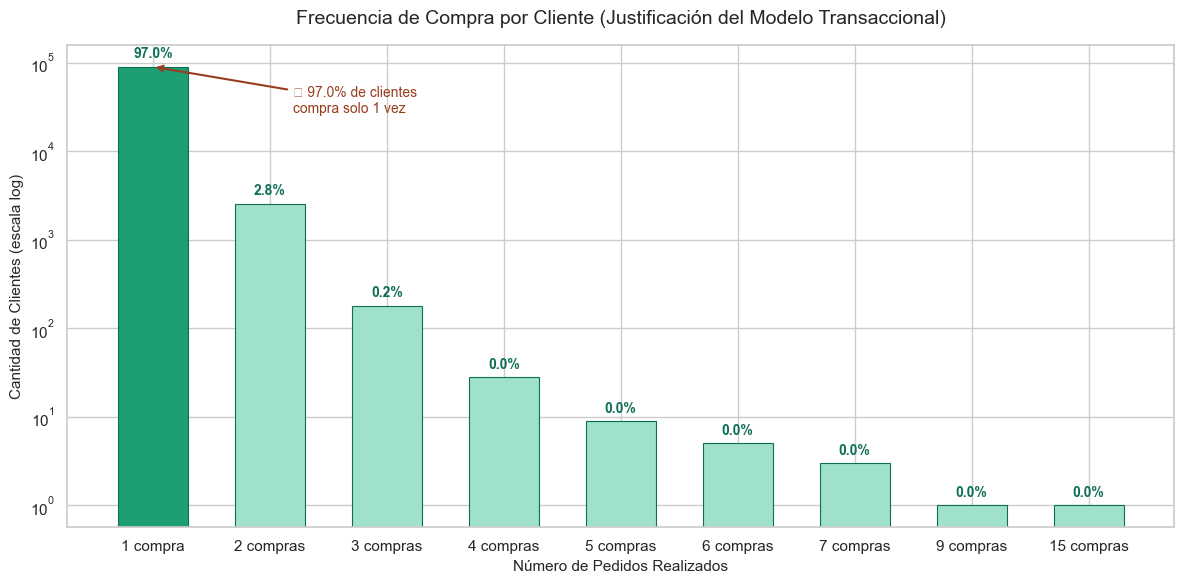

In [6]:
# --- GRÁFICO CORREGIDO: Distribución de Frecuencia de Compra ---
freq_counts = compras_por_cliente['total_orders'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

# 1. Usamos un rango numérico basado en el largo de los datos para las posiciones X (0, 1, 2...)
x_positions = range(len(freq_counts))

bars = ax.bar(
    x_positions, # Posición numérica fija
    freq_counts.values,
    color=['#1D9E75' if i == 0 else '#9FE1CB' for i in range(len(freq_counts))],
    edgecolor='#0F6E56',
    linewidth=0.8,
    width=0.6
)

# Escala logarítmica en Y
ax.set_yscale('log')

# Etiquetas de porcentaje sobre cada barra
total = freq_counts.sum()
for bar in bars:
    val = bar.get_height()
    pct = val / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.15,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10, color='#0F6E56', fontweight='bold'
    )

ax.set_title('Frecuencia de Compra por Cliente (Justificación del Modelo Transaccional)', pad=15)
ax.set_xlabel('Número de Pedidos Realizados')
ax.set_ylabel('Cantidad de Clientes (escala log)')

# 2. SE ALINEAN LAS ETIQUETAS: Usamos las mismas posiciones numéricas (0, 1, 2...)
ax.set_xticks(x_positions)
# Usamos el índice real de freq_counts para que el texto coincida exactamente (1 compra, 2 compras, etc.)
ax.set_xticklabels([f'{int(i)} compra{"s" if i > 1 else ""}' for i in freq_counts.index])

# Anotación de negocio (ahora apunta correctamente al índice 0)
ax.annotate(
    f'⚠ {freq_counts.iloc[0]/total*100:.1f}% de clientes\ncompra solo 1 vez',
    xy=(0, freq_counts.iloc[0]), # xy=(0, ...) se alinea con la primera barra
    xytext=(1.2, freq_counts.iloc[0] * 0.3),
    fontsize=10,
    color='#993C1D',
    arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1.5)
)

plt.tight_layout()
plt.show()

## 💰 PASO 5: Análisis Monetario (Ticket Promedio)
Descubrimos cuánto gasta el cliente antes de entrar en inactividad.

In [7]:
# Métricas monetarias por cliente único
monetary_stats = df_master.groupby('customer_unique_id')['payment_value'].agg(['sum', 'mean']).reset_index()
monetary_stats.columns = ['customer_unique_id', 'gasto_total', 'ticket_promedio']

print("💰 Resumen Estadístico de Consumo (R$):")
display(monetary_stats[['gasto_total', 'ticket_promedio']].describe().round(2))

💰 Resumen Estadístico de Consumo (R$):


,gasto_total,ticket_promedio
count,93358.00,93357.00
mean,165.20,160.32
std,226.31,219.57
min,0.00,9.59
25%,63.05,62.37
50%,107.78,105.63
75%,182.56,176.65
max,13664.08,13664.08


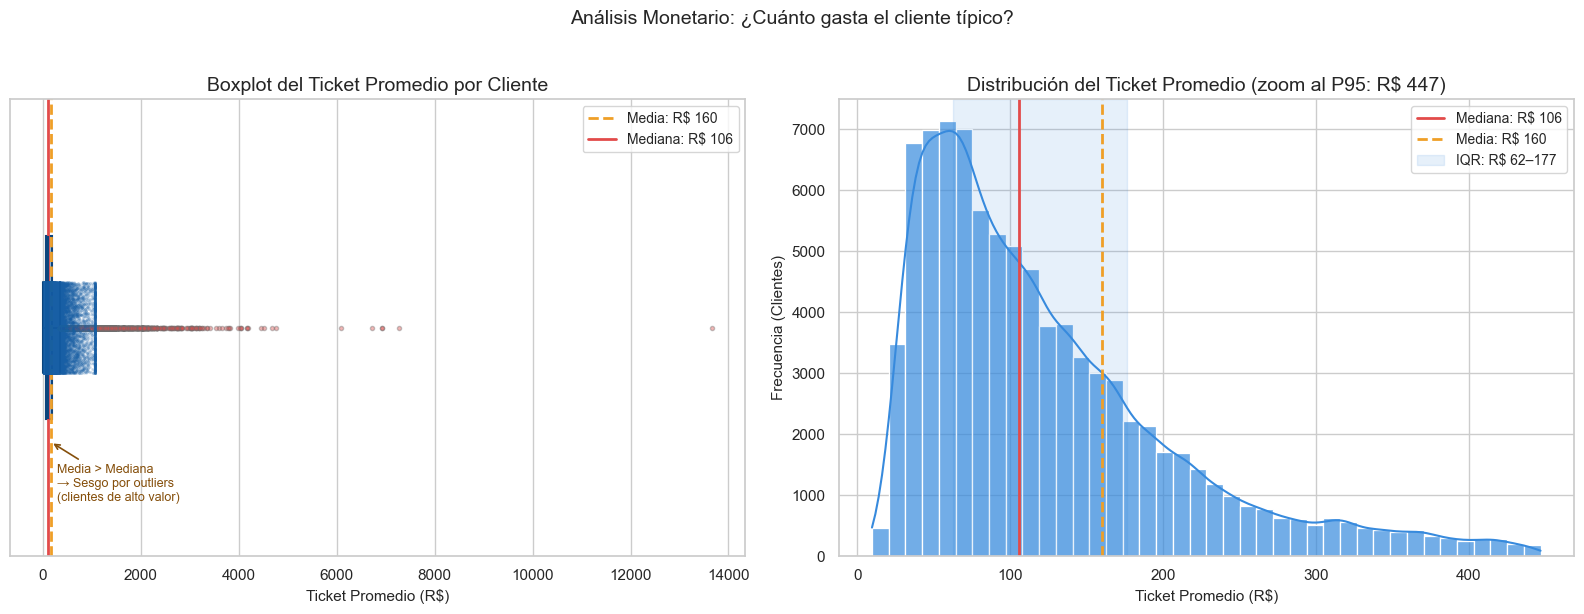


📊 INSIGHT MONETARIO:
   Mediana del ticket:  R$ 105.63  ← cliente típico
   Media del ticket:    R$ 160.32  ← inflada por outliers
   IQR (P25–P75):       R$ 62.37 – R$ 176.65
   Clientes sobre P95:  4666 (5.0%)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo de línea para el boxplot
line_style = {'color': '#0C447C'}

# --- GRÁFICO: Distribución del Ticket Promedio con Estadísticas Clave ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel izquierdo: Boxplot horizontal con stripplot ---
sns.boxplot(
    x=monetary_stats['ticket_promedio'],
    ax=axes[0],
    color='#85B7EB',
    # Aplicamos el color a todos los elementos del boxplot
    medianprops=line_style,
    whiskerprops=line_style,
    capprops=line_style,
    boxprops={'edgecolor': '#0C447C'},
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=3, alpha=0.4),
    width=0.4
)

sns.stripplot(
    x=monetary_stats['ticket_promedio'].clip(upper=monetary_stats['ticket_promedio'].quantile(0.99)),
    ax=axes[0],
    color='#185FA5',
    alpha=0.15,
    size=2,
    jitter=True
)

# Línea de media y mediana
media = monetary_stats['ticket_promedio'].mean()
mediana = monetary_stats['ticket_promedio'].median()
axes[0].axvline(media,   color='#EF9F27', linestyle='--', lw=2, label=f'Media: R$ {media:.0f}')
axes[0].axvline(mediana, color='#E24B4A', linestyle='-',  lw=2, label=f'Mediana: R$ {mediana:.0f}')

axes[0].set_title('Boxplot del Ticket Promedio por Cliente')
axes[0].set_xlabel('Ticket Promedio (R$)')
axes[0].set_yticks([])
axes[0].legend(fontsize=10)

# Anotación de insight
axes[0].annotate(
    f'Media > Mediana\n→ Sesgo por outliers\n(clientes de alto valor)',
    xy=(media, 0.25),
    xytext=(media * 1.8, 0.38),
    fontsize=9, color='#854F0B',
    arrowprops=dict(arrowstyle='->', color='#854F0B', lw=1.2)
)

# --- Panel derecho: Histograma acotado al P95 ---
p95 = monetary_stats['ticket_promedio'].quantile(0.95)
data_zoom = monetary_stats[monetary_stats['ticket_promedio'] <= p95]['ticket_promedio']

sns.histplot(data_zoom, bins=40, kde=True, color='#378ADD', ax=axes[1], alpha=0.7)
axes[1].axvline(mediana, color='#E24B4A', linestyle='-',  lw=2, label=f'Mediana: R$ {mediana:.0f}')
axes[1].axvline(media,   color='#EF9F27', linestyle='--', lw=2, label=f'Media: R$ {media:.0f}')

q25 = monetary_stats['ticket_promedio'].quantile(0.25)
q75 = monetary_stats['ticket_promedio'].quantile(0.75)
axes[1].axvspan(q25, q75, alpha=0.12, color='#378ADD', label=f'IQR: R$ {q25:.0f}–{q75:.0f}')

axes[1].set_title(f'Distribución del Ticket Promedio (zoom al P95: R$ {p95:.0f})')
axes[1].set_xlabel('Ticket Promedio (R$)')
axes[1].set_ylabel('Frecuencia (Clientes)')
axes[1].legend(fontsize=10)

plt.suptitle('Análisis Monetario: ¿Cuánto gasta el cliente típico?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Resumen ejecutivo en texto ---
print(f"\n📊 INSIGHT MONETARIO:")
print(f"   Mediana del ticket:  R$ {mediana:.2f}  ← cliente típico")
print(f"   Media del ticket:    R$ {media:.2f}  ← inflada por outliers")
print(f"   IQR (P25–P75):       R$ {q25:.2f} – R$ {q75:.2f}")
print(f"   Clientes sobre P95:  {(monetary_stats['ticket_promedio'] > p95).sum()} ({(monetary_stats['ticket_promedio'] > p95).mean()*100:.1f}%)")

## 📉 PASO 6: Recencia y Definición Matemática del Churn
Simulamos un cierre de datos (`snapshot_date`) y medimos los días de inactividad de cada cliente único para validar el umbral de **180 días**.

In [9]:
# 1. Definir fecha de corte
snapshot_date = df_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Calcular recencia
df_churn_final = df_master.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days
}).reset_index()
df_churn_final.columns = ['customer_unique_id', 'recencia']

# 3. Aplicar umbral estipulado
UMBRAL = 180
df_churn_final['is_churn'] = df_churn_final['recencia'] > UMBRAL

print(f"📊 Proporción de Churn con Umbral > {UMBRAL} días:")
print(df_churn_final['is_churn'].value_counts(normalize=True).map("{:.2%}".format))

📊 Proporción de Churn con Umbral > 180 días:
is_churn
True     59.18%
False    40.82%
Name: proportion, dtype: object


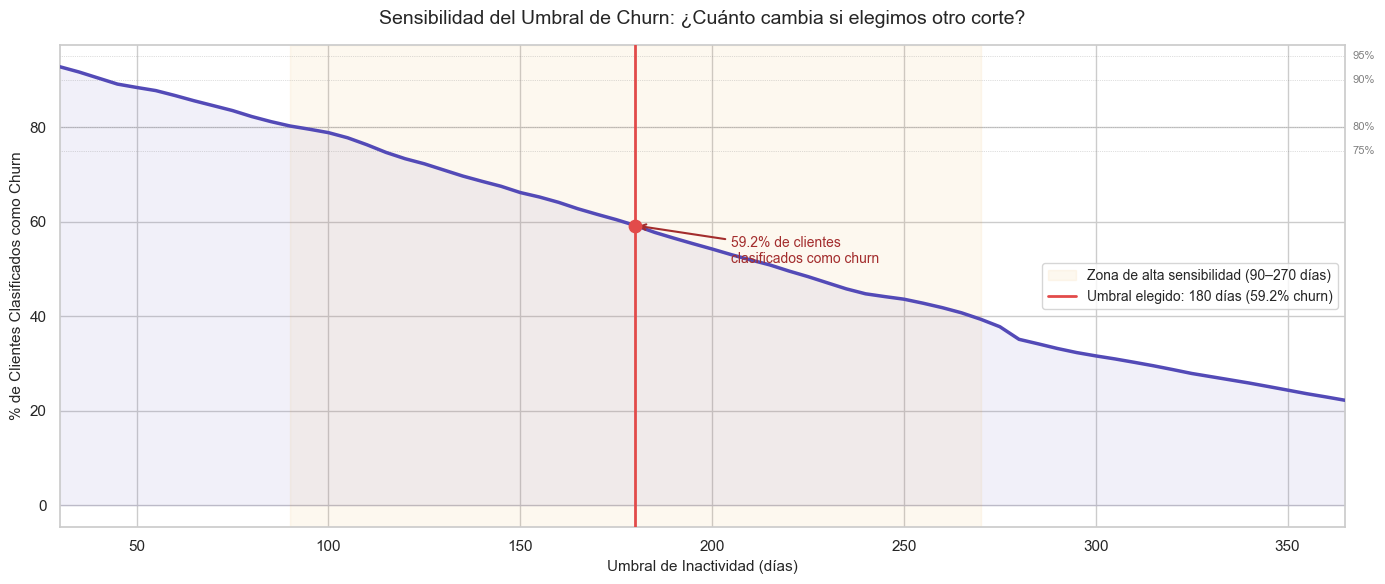


📊 TABLA DE SENSIBILIDAD — PUNTOS CLAVE:
    Umbral |    % Churn |   # Clientes Churn
---------------------------------------------
        60 |      86.7% |             80,921
        90 |      80.2% |             74,899
       120 |      73.3% |             68,438
       150 |      66.2% |             61,761
       180 |      59.2% |             55,252 ← ELEGIDO
       240 |      44.7% |             41,766
       270 |      39.4% |             36,743
       365 |      22.2% |             20,738


In [10]:
# --- GRÁFICO: Curva de Sensibilidad del Umbral de Churn ---
umbrales = range(30, 366, 5)
pct_churn_por_umbral = [
    (df_churn_final['recencia'] > u).mean() * 100
    for u in umbrales
]

# Valor exacto en el umbral elegido
pct_180 = (df_churn_final['recencia'] > UMBRAL).mean() * 100

fig, ax = plt.subplots(figsize=(14, 6))

# Curva principal
ax.plot(list(umbrales), pct_churn_por_umbral,
        color='#534AB7', linewidth=2.5, zorder=3)

# Relleno bajo la curva
ax.fill_between(list(umbrales), pct_churn_por_umbral,
                alpha=0.08, color='#534AB7')

# Zona de alta sensibilidad (90–270 días)
ax.axvspan(90, 270, alpha=0.07, color='#EF9F27',
           label='Zona de alta sensibilidad (90–270 días)')

# Línea vertical del umbral elegido
ax.axvline(UMBRAL, color='#E24B4A', linewidth=2, zorder=4,
           label=f'Umbral elegido: {UMBRAL} días ({pct_180:.1f}% churn)')

# Punto destacado
ax.scatter([UMBRAL], [pct_180], color='#E24B4A', s=80, zorder=5)

# Anotación del punto
ax.annotate(
    f'{pct_180:.1f}% de clientes\nclasificados como churn',
    xy=(UMBRAL, pct_180),
    xytext=(UMBRAL + 25, pct_180 - 8),
    fontsize=10, color='#A32D2D',
    arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.5)
)

# Líneas de referencia horizontales
for nivel, etiqueta in [(75, '75%'), (80, '80%'), (90, '90%'), (95, '95%')]:
    ax.axhline(nivel, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
    ax.text(367, nivel, etiqueta, va='center', fontsize=8, color='gray')

ax.set_title(
    f'Sensibilidad del Umbral de Churn: ¿Cuánto cambia si elegimos otro corte?',
    pad=15
)
ax.set_xlabel('Umbral de Inactividad (días)')
ax.set_ylabel('% de Clientes Clasificados como Churn')
ax.set_xlim(30, 365)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- Tabla de referencia en puntos clave ---
print("\n📊 TABLA DE SENSIBILIDAD — PUNTOS CLAVE:")
print(f"{'Umbral':>10} | {'% Churn':>10} | {'# Clientes Churn':>18}")
print("-" * 45)
for u in [60, 90, 120, 150, 180, 240, 270, 365]:
    n = (df_churn_final['recencia'] > u).sum()
    p = (df_churn_final['recencia'] > u).mean() * 100
    marca = " ← ELEGIDO" if u == UMBRAL else ""
    print(f"{u:>10} | {p:>9.1f}% | {n:>18,}{marca}")

## 🎨 PASO 7: Visualizaciones de Nivel Ejecutivo (Seaborn)
Dos gráficos de alto impacto para la presentación del proyecto.

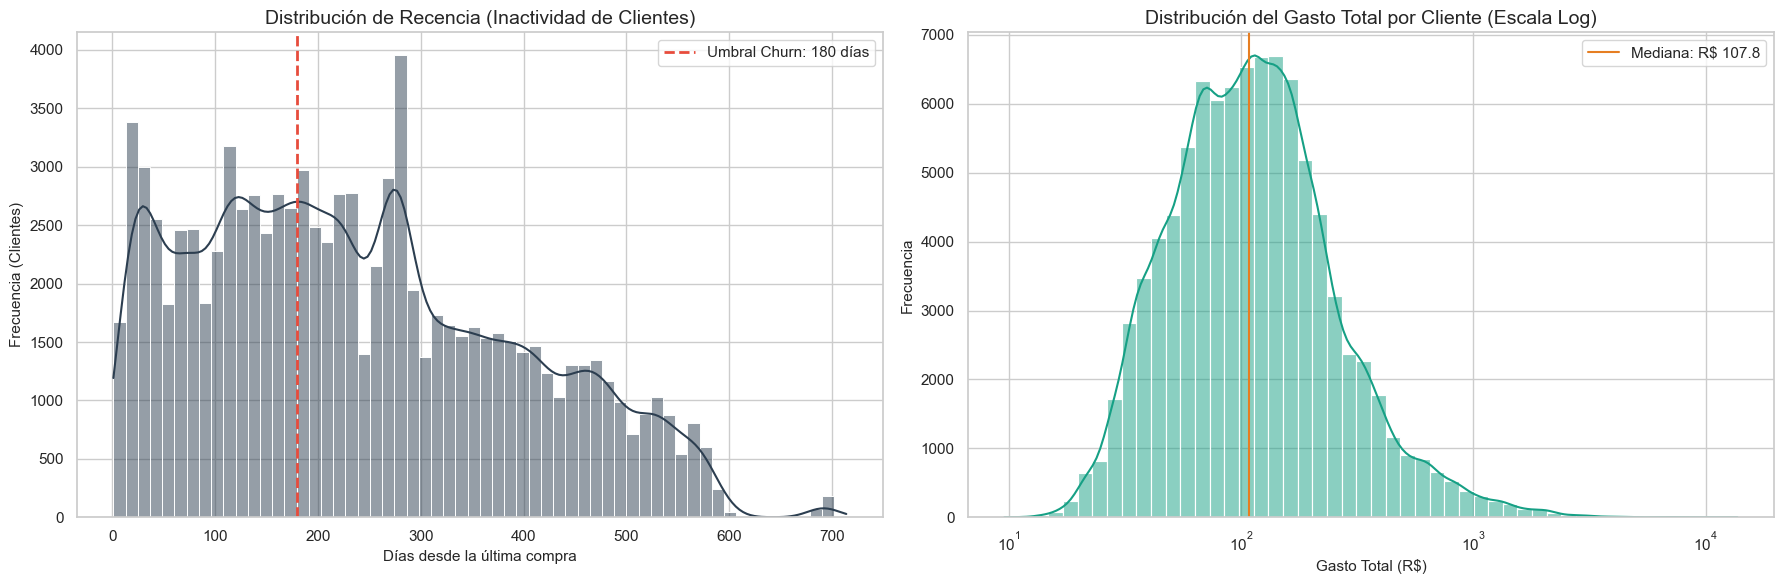

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuración de los gráficos ---
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Histograma de Recencia con Umbral de Churn
sns.histplot(df_churn_final['recencia'], bins=60, kde=True, color='#2c3e50', ax=ax[0])
ax[0].axvline(180, color='#e74c3c', linestyle='--', linewidth=2, label='Umbral Churn: 180 días')
ax[0].set_title('Distribución de Recencia (Inactividad de Clientes)')
ax[0].set_xlabel('Días desde la última compra')
ax[0].set_ylabel('Frecuencia (Clientes)')
ax[0].legend()

# Gráfico 2: Distribución del Gasto en escala logarítmica
# Filtramos valores > 0 para evitar el error con log_scale (log(0) es -inf)
gasto_valido = monetary_stats['gasto_total'][monetary_stats['gasto_total'] > 0]

sns.histplot(
    gasto_valido, 
    bins=50, 
    kde=True, 
    color='#16a085', 
    log_scale=True, 
    ax=ax[1]
)

# Línea de mediana (usando el valor calculado sobre la serie original)
mediana_gasto = monetary_stats['gasto_total'].median()
ax[1].axvline(
    mediana_gasto, 
    color='#e67e22', 
    linestyle='-', 
    label=f"Mediana: R$ {mediana_gasto:.1f}"
)

ax[1].set_title('Distribución del Gasto Total por Cliente (Escala Log)')
ax[1].set_xlabel('Gasto Total (R$)')
ax[1].set_ylabel('Frecuencia')
ax[1].legend()

# Ajuste final de layout
plt.tight_layout()
plt.show()

## 🌟 PASO 8: Análisis de Satisfacción (Churn vs. Review Score)
¿La mala experiencia de compra predice el Churn? Cruzamos la tasa de abandono con las calificaciones de los clientes.

✅ Correlación calculada entre Churn y Satisfacción.
Review Score promedio por grupo:


,review_score
is_churn,
False,4.20
True,4.12


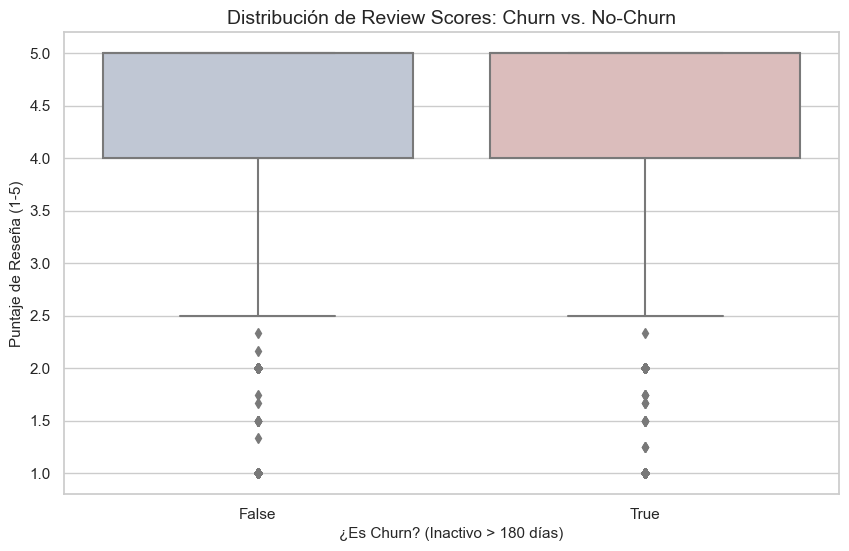

In [12]:
# 1. Consolidar reviews por orden (promedio de score por order_id)
reviews_avg = reviews.groupby('order_id')['review_score'].mean().reset_index()

# 2. Unir con df_master para vincular Review con el Cliente Único
df_satisfaction = pd.merge(df_master[['order_id', 'customer_unique_id']], 
                           reviews_avg, on='order_id', how='left')

# 3. Calcular el score promedio por Cliente Único
customer_satisfaction = df_satisfaction.groupby('customer_unique_id')['review_score'].mean().reset_index()

# 4. Unir con el target de Churn (df_churn_final)
df_final_analysis = pd.merge(df_churn_final, customer_satisfaction, on='customer_unique_id')

print("✅ Correlación calculada entre Churn y Satisfacción.")
print("Review Score promedio por grupo:")
display(df_final_analysis.groupby('is_churn')['review_score'].mean().to_frame().round(2))

# Visualización de la diferencia
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final_analysis, x='is_churn', y='review_score', palette='vlag')
plt.title('Distribución de Review Scores: Churn vs. No-Churn')
plt.xlabel('¿Es Churn? (Inactivo > 180 días)')
plt.ylabel('Puntaje de Reseña (1-5)')
plt.show()

## 🚚 PASO 8.5: Pre-cálculo de Logística (necesario para el heatmap)
El heatmap del Paso 8 cruza `delivery_delay`, pero esa variable se construye en el Paso 9. Para que el notebook corra de principio a fin sin `NameError`, calculamos aquí las features de logística. El Paso 9 las vuelve a calcular para su narrativa (es idempotente, no genera problemas).


In [13]:
# Retraso de entrega en días (positivo = tarde, negativo = anticipado)
df_master['delivery_delay'] = (
    df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']
).dt.days

# Peor retraso experimentado por cada cliente único
customer_logistics = (
    df_master.groupby('customer_unique_id')['delivery_delay'].max().reset_index()
)

# Target de churn + logística (lo usa el Paso 9 más abajo)
df_final_logistics = pd.merge(df_churn_final, customer_logistics, on='customer_unique_id')

print('✅ Features de logística pre-calculadas para el heatmap.')


✅ Features de logística pre-calculadas para el heatmap.


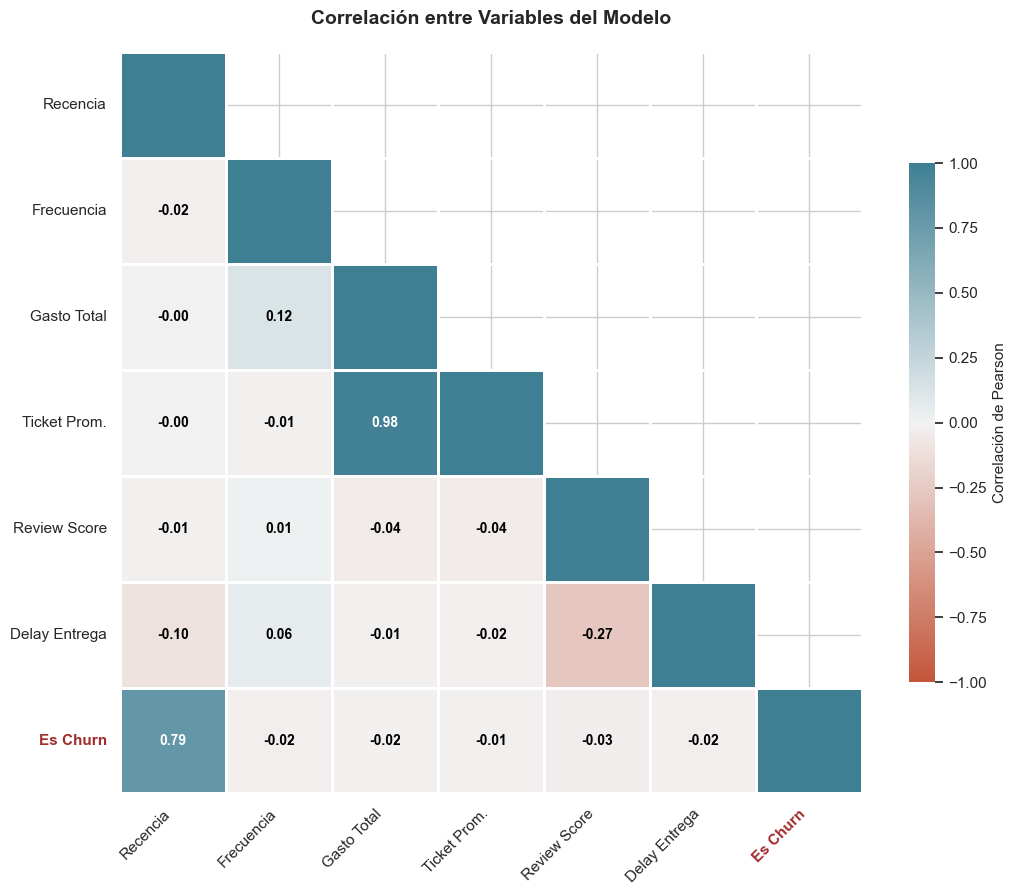


📊 CORRELACIÓN DE CADA VARIABLE CON EL TARGET (Es Churn):
---------------------------------------------
  Recencia           +0.794  ███████████████
  Review Score       -0.027  
  Delay Entrega      -0.016  
  Frecuencia         -0.016  
  Gasto Total        -0.015  
  Ticket Prom.       -0.013  

⚠️  PARES CON ALTA MULTICOLINEALIDAD (|r| > 0.7):
  Recencia ↔ Es Churn: r = 0.794
  Gasto Total ↔ Ticket Prom.: r = 0.983


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Preparación de Datos ---
# Aseguramos que las variables estén correctamente preparadas
df_heatmap = df_final_analysis.copy()
df_heatmap = pd.merge(df_heatmap, customer_logistics, on='customer_unique_id', how='left')
df_heatmap = pd.merge(df_heatmap, compras_por_cliente, on='customer_unique_id', how='left')
df_heatmap = pd.merge(df_heatmap, monetary_stats, on='customer_unique_id', how='left')

vars_heatmap = df_heatmap[['recencia', 'total_orders', 'gasto_total', 'ticket_promedio', 'review_score', 'delivery_delay', 'is_churn']].copy()
vars_heatmap['is_churn'] = vars_heatmap['is_churn'].astype(int)

vars_heatmap.columns = ['Recencia', 'Frecuencia', 'Gasto Total', 'Ticket Prom.', 'Review Score', 'Delay Entrega', 'Es Churn']
corr_matrix = vars_heatmap.corr()

# --- 2. Configuración del Heatmap ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))

# Dibujar heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,  # Desactivamos el auto-annot para usar nuestro propio bucle
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Correlación de Pearson'},
    ax=ax
)

# --- 3. Forzar escritura de etiquetas (Solución al error de visualización) ---
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        value = corr_matrix.iloc[i, j]
        # Seleccionamos color del texto según el fondo para mejor contraste
        text_color = 'white' if abs(value) > 0.4 else 'black'
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                ha='center', va='center', 
                color=text_color, fontsize=10, fontweight='bold')

# --- 4. Estilo y Formato ---
ax.set_title('Correlación entre Variables del Modelo', pad=20, fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Resaltar la fila/columna 'Es Churn'
for tick in ax.get_xticklabels():
    if tick.get_text() == 'Es Churn': tick.set_color('#A32D2D'); tick.set_weight('bold')
for tick in ax.get_yticklabels():
    if tick.get_text() == 'Es Churn': tick.set_color('#A32D2D'); tick.set_weight('bold')

plt.tight_layout()
plt.show()

# --- 5. Insight Textual ---
corr_con_churn = corr_matrix['Es Churn'].drop('Es Churn').sort_values(key=abs, ascending=False)
print("\n📊 CORRELACIÓN DE CADA VARIABLE CON EL TARGET (Es Churn):")
print("-" * 45)
for var, val in corr_con_churn.items():
    barra = '█' * int(abs(val) * 20)
    signo = '+' if val > 0 else '-'
    print(f"  {var:<18} {signo}{abs(val):.3f}  {barra}")

print("\n⚠️  PARES CON ALTA MULTICOLINEALIDAD (|r| > 0.7):")
encontrado = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.7:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {v:.3f}")
            encontrado = True
if not encontrado: print("  Ningún par supera el umbral de 0.7")

## 🚚 PASO 9: Impacto de la Logística (Retrasos en la Entrega)
¿Un cliente se va porque el pedido llegó después de la fecha prometida? Calculamos el 'delay' (Retraso real vs. Estimado).

✅ Análisis de logística completado.
Días de retraso promedio (Comparativa):


,delivery_delay
is_churn,
False,-11.52
True,-11.85


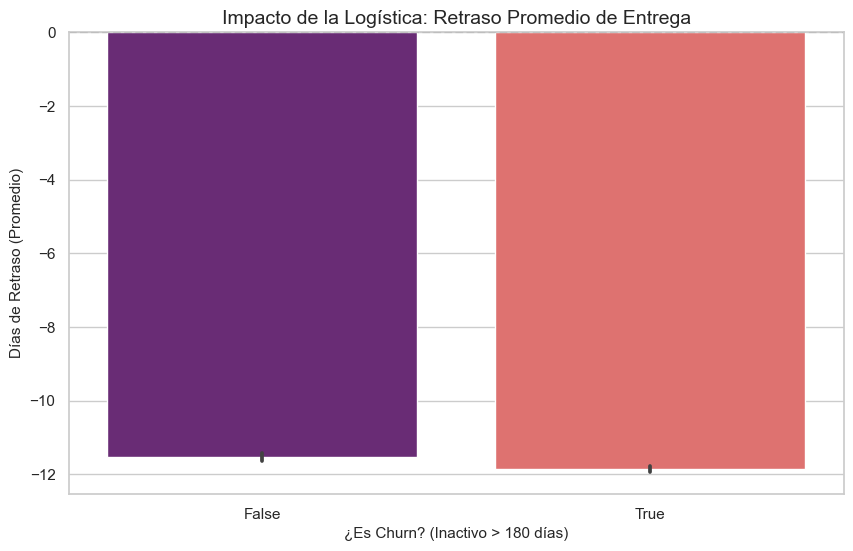

In [15]:
# 1. Calcular el retraso en días (Valores positivos = Tarde | Valores negativos = Antes de tiempo)
df_master['delivery_delay'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.days

# 2. Obtener el retraso máximo experimentado por cada cliente único
customer_logistics = df_master.groupby('customer_unique_id')['delivery_delay'].max().reset_index()

# 3. Unir con el target de Churn
df_final_logistics = pd.merge(df_churn_final, customer_logistics, on='customer_unique_id')

print("✅ Análisis de logística completado.")
print("Días de retraso promedio (Comparativa):")
display(df_final_logistics.groupby('is_churn')['delivery_delay'].mean().to_frame().round(2))

# Visualización: ¿Es mayor el retraso en los clientes que se van?
plt.figure(figsize=(10, 6))
sns.barplot(data=df_final_logistics, x='is_churn', y='delivery_delay', palette='magma')
plt.title('Impacto de la Logística: Retraso Promedio de Entrega')
plt.xlabel('¿Es Churn? (Inactivo > 180 días)')
plt.ylabel('Días de Retraso (Promedio)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

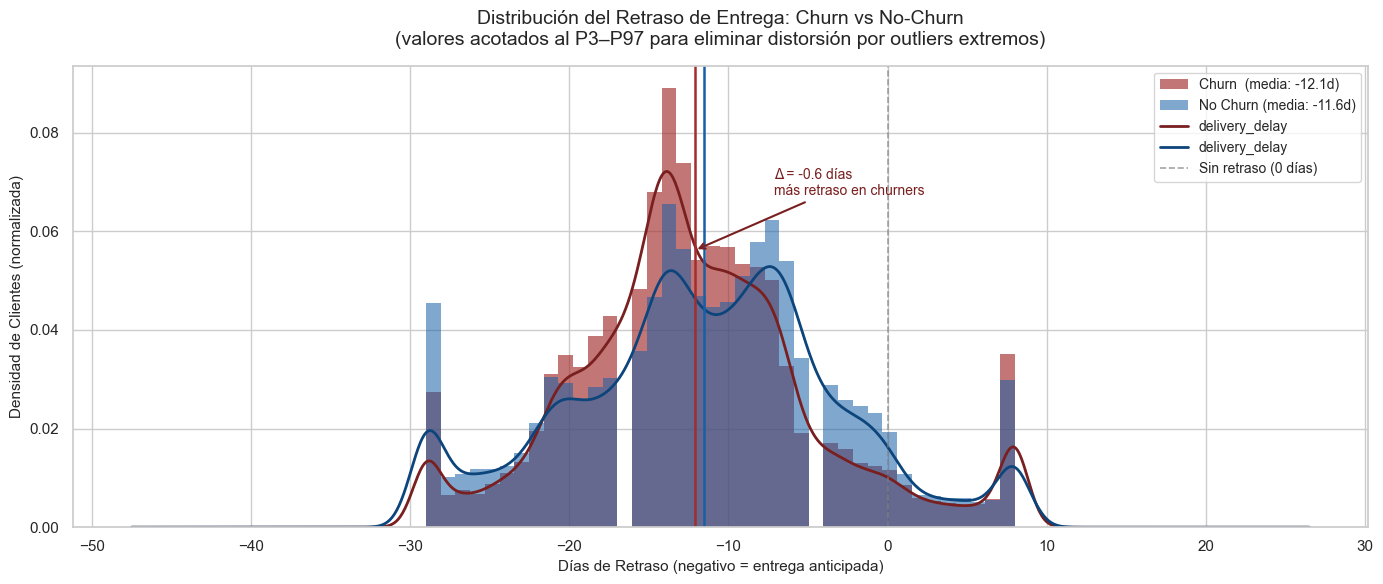


📊 COMPARATIVA DE RETRASO: CHURN vs NO-CHURN
--------------------------------------------------


,mean,std,25%,50%,75%,max
No Churn,-11.52,9.83,-17.0,-11.0,-6.0,106.0
Churn,-11.85,10.42,-17.0,-13.0,-8.0,188.0



⚠️  INSIGHT: Los churners experimentaron en promedio -0.6 días más de retraso.
   Sin embargo, la diferencia es moderada —
   la logística es un factor secundario respecto a la recencia.


In [16]:
# --- GRÁFICO: Distribución del Delay superpuesta Churn vs No-Churn ---

# Separar los dos grupos con delay acotado al P97 (evita distorsión por outliers extremos)
p97 = df_final_logistics['delivery_delay'].quantile(0.97)
p03 = df_final_logistics['delivery_delay'].quantile(0.03)

delay_churn    = df_final_logistics[df_final_logistics['is_churn']  == True]['delivery_delay'].clip(p03, p97)
delay_nochurn  = df_final_logistics[df_final_logistics['is_churn']  == False]['delivery_delay'].clip(p03, p97)

media_churn   = delay_churn.mean()
media_nochurn = delay_nochurn.mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Histogramas superpuestos normalizados
ax.hist(delay_churn,   bins=40, density=True, alpha=0.65,
        color='#A32D2D', label=f'Churn  (media: {media_churn:.1f}d)',   edgecolor='none')
ax.hist(delay_nochurn, bins=40, density=True, alpha=0.55,
        color='#185FA5', label=f'No Churn (media: {media_nochurn:.1f}d)', edgecolor='none')

# KDE suavizado encima
delay_churn.plot.kde(ax=ax,   color='#791F1F', linewidth=2)
delay_nochurn.plot.kde(ax=ax, color='#0C447C', linewidth=2)

# Línea de cero (sin retraso)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Sin retraso (0 días)')

# Líneas de media por grupo
ax.axvline(media_churn,   color='#A32D2D', linestyle='-',  linewidth=1.8)
ax.axvline(media_nochurn, color='#185FA5', linestyle='-',  linewidth=1.8)

# Anotación de diferencia
diff = media_churn - media_nochurn
ax.annotate(
    f'Δ = {diff:.1f} días\nmás retraso en churners',
    xy=(media_churn, ax.get_ylim()[1] * 0.6),
    xytext=(media_churn + 5, ax.get_ylim()[1] * 0.72),
    fontsize=10, color='#791F1F',
    arrowprops=dict(arrowstyle='->', color='#791F1F', lw=1.5)
)

ax.set_title(
    'Distribución del Retraso de Entrega: Churn vs No-Churn\n'
    '(valores acotados al P3–P97 para eliminar distorsión por outliers extremos)',
    pad=15
)
ax.set_xlabel('Días de Retraso (negativo = entrega anticipada)')
ax.set_ylabel('Densidad de Clientes (normalizada)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- Resumen estadístico comparativo ---
print("\n📊 COMPARATIVA DE RETRASO: CHURN vs NO-CHURN")
print("-" * 50)
stats = df_final_logistics.groupby('is_churn')['delivery_delay'].describe().round(2)
stats.index = ['No Churn', 'Churn']
display(stats[['mean', 'std', '25%', '50%', '75%', 'max']])

print(f"\n⚠️  INSIGHT: Los churners experimentaron en promedio {diff:.1f} días más de retraso.")
print(f"   Sin embargo, la diferencia es {'moderada' if abs(diff) < 5 else 'significativa'} —")
print(f"   la logística es un factor {'secundario' if abs(diff) < 5 else 'relevante'} respecto a la recencia.")

## 💎 PASO 10: Construcción de la ABT (Analytical Base Table)
Consolidamos todas las variables calculadas en una única tabla maestra por cliente único. Esta será la entrada para nuestros modelos de Machine Learning.

In [17]:
# 1. Empezamos con nuestra base de Churn (Recencia + Target)
abt = df_churn_final.copy()

# 2. Unimos Frecuencia (Paso 4)
abt = pd.merge(abt, compras_por_cliente, on='customer_unique_id', how='left')

# 3. Unimos Monetario (Paso 5)
abt = pd.merge(abt, monetary_stats, on='customer_unique_id', how='left')

# 4. Unimos Satisfacción (Paso 8)
abt = pd.merge(abt, customer_satisfaction, on='customer_unique_id', how='left')

# 5. Unimos Logística (Paso 9)
abt = pd.merge(abt, customer_logistics, on='customer_unique_id', how='left')

# --- Tratamiento de Nulos en la ABT ---
# Si un cliente no dejó review, imputamos con la media global para no perder el registro
abt['review_score'] = abt['review_score'].fillna(abt['review_score'].mean())

# Si el delay es nulo (órdenes no entregadas o datos faltantes), imputamos con 0 (sin retraso)
abt['delivery_delay'] = abt['delivery_delay'].fillna(0)

print("✅ ABT construida con éxito.")
print(f"Dimensiones finales: {abt.shape}")
print("\nPrimeras filas de la ABT:")
display(abt.head())

# 6. Guardar la ABT para el Sprint 2 (Modelado)
abt.to_csv(PATH + 'abt_churn_olist.csv', index=False)
print(f"\n💾 Archivo guardado en: {PATH}abt_churn_olist.csv")

✅ ABT construida con éxito.
Dimensiones finales: (93358, 8)

Primeras filas de la ABT:


,customer_unique_id,recencia,is_churn,total_orders,gasto_total,ticket_promedio,review_score,delivery_delay
0,0000366f3b9a7992bf8c76cfdf3221e2,112,False,1,141.90,141.90,5.0,-5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,False,1,27.19,27.19,4.0,-5.0
2,0000f46a3911fa3c0805444483337064,537,True,1,86.22,86.22,3.0,-2.0
3,0000f6ccb0745a6a4b88665a16c9f078,321,True,1,43.62,43.62,4.0,-12.0
4,0004aac84e0df4da2b147fca70cf8255,288,True,1,196.89,196.89,5.0,-8.0



💾 Archivo guardado en: dataset/abt_churn_olist.csv


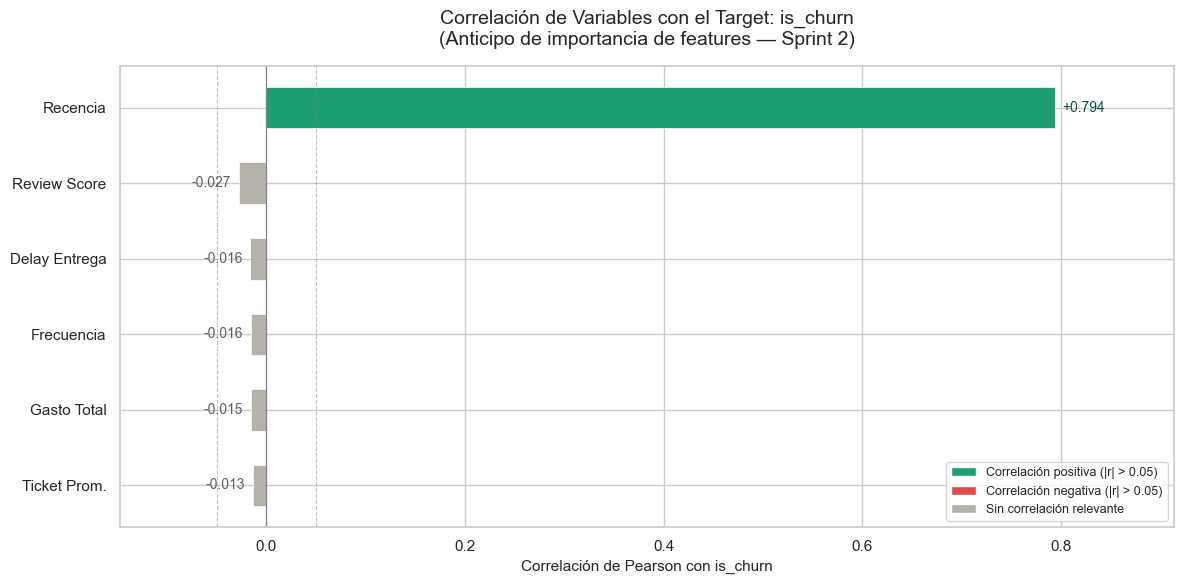


🏁 RESUMEN EJECUTIVO — ABT LISTA PARA SPRINT 2
  Predictor dominante : Recencia (r = +0.794)
  Variables de señal débil: Ticket Prom., Gasto Total, Frecuencia, Delay Entrega, Review Score

  → El modelo de ML deberá compensar el desbalance de
    señal: 'Recencia' domina; las demás variables aportan
    contexto complementario, no poder predictivo directo.

💾 Guardando ABT en disco...


In [18]:
# --- GRÁFICO: Correlación de cada variable de la ABT con el target is_churn ---

# Variables numéricas de la ABT (excluyendo IDs y el propio target)
vars_abt = ['recencia', 'total_orders', 'gasto_total',
            'ticket_promedio', 'review_score', 'delivery_delay']

etiquetas = {
    'recencia'        : 'Recencia',
    'total_orders'    : 'Frecuencia',
    'gasto_total'     : 'Gasto Total',
    'ticket_promedio' : 'Ticket Prom.',
    'review_score'    : 'Review Score',
    'delivery_delay'  : 'Delay Entrega'
}

# Calcular correlación de cada variable con is_churn
abt_num = abt.copy()
abt_num['is_churn'] = abt_num['is_churn'].astype(int)

corr_target = (
    abt_num[vars_abt + ['is_churn']]
    .corr()['is_churn']
    .drop('is_churn')
    .rename(etiquetas)
    .sort_values(key=abs, ascending=True)  # ascending=True para barplot horizontal
)

# Colores según signo y magnitud
def color_barra(v):
    if v > 0.05:  return '#1D9E75'
    if v < -0.05: return '#E24B4A'
    return '#B4B2A9'

colores = [color_barra(v) for v in corr_target.values]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    corr_target.index,
    corr_target.values,
    color=colores,
    edgecolor='white',
    linewidth=0.5,
    height=0.55
)

# Valor al lado de cada barra
for bar, val in zip(bars, corr_target.values):
    offset = 0.008 if val >= 0 else -0.008
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(
        val + offset, bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center', ha=ha, fontsize=10,
        color='#085041' if val > 0.05 else '#A32D2D' if val < -0.05 else '#5F5E5A'
    )

# Línea de referencia en 0
ax.axvline(0, color='gray', linewidth=0.8, linestyle='-')

# Umbrales de relevancia
for umbral in [0.05, -0.05]:
    ax.axvline(umbral, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_title(
    'Correlación de Variables con el Target: is_churn\n'
    '(Anticipo de importancia de features — Sprint 2)',
    pad=15
)
ax.set_xlabel('Correlación de Pearson con is_churn')
ax.set_xlim(
    corr_target.min() - 0.12,
    corr_target.max() + 0.12
)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#1D9E75', label='Correlación positiva (|r| > 0.05)'),
    Patch(facecolor='#E24B4A', label='Correlación negativa (|r| > 0.05)'),
    Patch(facecolor='#B4B2A9', label='Sin correlación relevante'),
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# --- Conclusión ejecutiva ---
top_var   = corr_target.abs().idxmax()
top_val   = corr_target.abs().max()
vars_bajas = corr_target[corr_target.abs() <= 0.05].index.tolist()

print("\n🏁 RESUMEN EJECUTIVO — ABT LISTA PARA SPRINT 2")
print("=" * 55)
print(f"  Predictor dominante : {top_var} (r = {corr_target[top_var]:+.3f})")
print(f"  Variables de señal débil: {', '.join(vars_bajas)}")
print(f"\n  → El modelo de ML deberá compensar el desbalance de")
print(f"    señal: 'Recencia' domina; las demás variables aportan")
print(f"    contexto complementario, no poder predictivo directo.")
print(f"\n💾 Guardando ABT en disco...")

🔄 Cargando datos complementarios de productos...

📝 TOP 10 CATEGORÍAS DE PRODUCTOS MÁS COMPRADAS
--------------------------------------------------
                               Unidades Vendidas
product_category_name_english                   
bed_bath_table                             10953
health_beauty                               9465
sports_leisure                              8431
furniture_decor                             8160
computers_accessories                       7644
housewares                                  6795
watches_gifts                               5859
telephony                                   4430
garden_tools                                4268
auto                                        4140
--------------------------------------------------


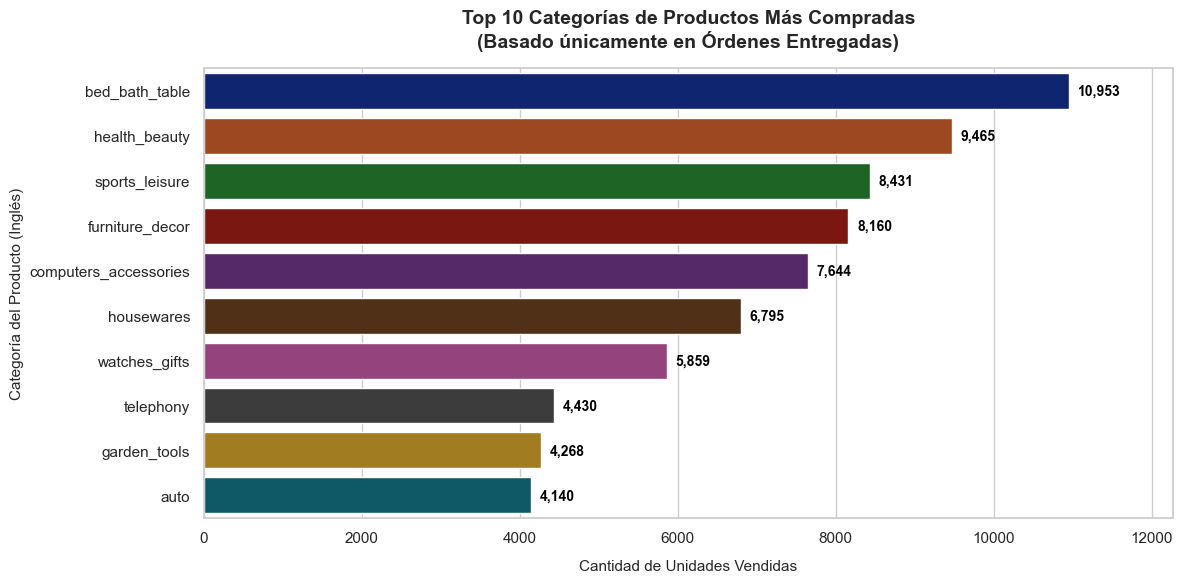


📝 TOP 5 PRODUCTOS ESPECÍFICOS (IDs) MÁS VENDIDOS
--------------------------------------------------
ID: aca2eb7d00ea1a7b8ebd4e68314663af 
🔹 Categoría: furniture_decor -> Vendidos: 520 unidades

ID: 422879e10f46682990de24d770e7f83d 
🔹 Categoría: garden_tools -> Vendidos: 484 unidades

ID: 99a4788cb24856965c36a24e339b6058 
🔹 Categoría: bed_bath_table -> Vendidos: 477 unidades

ID: 389d119b48cf3043d311335e499d9c6b 
🔹 Categoría: garden_tools -> Vendidos: 390 unidades

ID: 368c6c730842d78016ad823897a372db 
🔹 Categoría: garden_tools -> Vendidos: 388 unidades



In [19]:
# ==============================================================================
# 📊 PASO ADICIONAL: Análisis de los Top Productos y Categorías Más Vendidas
# ==============================================================================

print("🔄 Cargando datos complementarios de productos...")

# 1. Cargar el dataset de ítems de órdenes y el catálogo de productos
items = pd.read_csv(os.path.join(PATH, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(PATH, 'olist_products_dataset.csv'))

# 2. Cargar el mapa de traducción que subiste a tu entorno
translation = pd.read_csv(os.path.join(PATH, 'product_category_name_translation.csv'))

# 3. Filtrar los ítems para conservar SOLO las órdenes limpias (Delivered)
# Esto mantiene la consistencia con el filtro 'orders_clean' que definiste en el Paso 3
items_clean = items[items['order_id'].isin(orders_clean['order_id'])].copy()

# 4. Cruzar ítems con productos para obtener la categoría original en portugués
df_items_prod = pd.merge(items_clean, products[['product_id', 'product_category_name']], 
                        on='product_id', how='left')

# 5. Cruzar con la tabla de traducción para obtener los nombres en inglés
df_final_prod = pd.merge(df_items_prod, translation, on='product_category_name', how='left')

# Si alguna categoría no tiene traducción, rellenamos con el nombre original
df_final_prod['product_category_name_english'].fillna(df_final_prod['product_category_name'], inplace=True)

# 6. Calcular el Top 10 de categorías más vendidas
top_categories = df_final_prod['product_category_name_english'].value_counts().head(10)

print("\n📝 TOP 10 CATEGORÍAS DE PRODUCTOS MÁS COMPRADAS")
print("-" * 50)
print(top_categories.to_frame(name='Unidades Vendidas'))
print("-" * 50)

# 7. Visualización Gráfica (Respetando tu configuración del Paso 1: sns.set_theme)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_categories.values, y=top_categories.index, palette="dark")

# Agregar las etiquetas de valores numéricos al final de cada barra horizontal
for i, v in enumerate(top_categories.values):
    ax.text(v + (max(top_categories.values) * 0.01), i, f'{v:,}', 
            va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.title('Top 10 Categorías de Productos Más Compradas\n(Basado únicamente en Órdenes Entregadas)', 
          fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Cantidad de Unidades Vendidas', fontsize=11, labelpad=10)
plt.ylabel('Categoría del Producto (Inglés)', fontsize=11)
plt.xlim(0, max(top_categories.values) * 1.12) # Espacio dinámico para que no se corten las etiquetas
plt.tight_layout()
plt.show()

# 8. Opcional: Top 5 de Productos específicos más vendidos (SKU único)
print("\n📝 TOP 5 PRODUCTOS ESPECÍFICOS (IDs) MÁS VENDIDOS")
print("-" * 50)
top_products_id = df_final_prod['product_id'].value_counts().head(5)
for p_id, count in top_products_id.items():
    cat = df_final_prod[df_final_prod['product_id'] == p_id]['product_category_name_english'].values[0]
    print(f"ID: {p_id} \n🔹 Categoría: {cat} -> Vendidos: {count} unidades\n")

# Sprint 2: Modelado de Clasificación de Churn
### Objetivo: detectar clientes inactivos / en riesgo de abandono (`is_churn`)
**Métricas de evaluación:** Recall, F1 y AUC (no accuracy, por el fuerte desbalance de clases).

> ⚠️ **Decisión metodológica clave — fuga de datos (target leakage).**
> El target se definió como `is_churn = recencia > 180`. Es decir, `is_churn` es una > *función determinista* de `recencia`. Si incluyéramos `recencia` como feature, el modelo > simplemente reaprendería el umbral de 180 días y daría métricas perfectas pero **falsas** > (AUC≈1.0). Por eso `recencia` se **excluye** del conjunto de variables predictoras. > El modelo aprende a identificar churn a partir de señales de comportamiento > (frecuencia, gasto, satisfacción, logística), que es lo realmente útil para el negocio.

> 📌 **Nota honesta sobre los datos.** En Olist ~97% de los clientes compran una sola vez, > así que la señal predictiva de estas variables es débil (lo mostró la correlación de la ABT). > Los resultados serán *modestos*; eso es esperable y correcto, no un error del pipeline. > Al final dejamos esbozado el enfoque *production-grade* (ventana temporal de observación + > ventana de resultado) que resuelve la tautología de raíz.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay)

# --- Carga de la ABT (o usa la variable `abt` ya en memoria) ---
# abt = pd.read_csv(PATH + 'abt_churn_olist.csv')

# Features: TODO menos el id y `recencia` (que define el target -> fuga)
FEATURES = ['total_orders', 'gasto_total', 'ticket_promedio',
            'review_score', 'delivery_delay']

X = abt[FEATURES].copy()
y = abt['is_churn'].astype(int)

print('Balance de clases (1 = churn):')
print(y.value_counts(normalize=True).map('{:.2%}'.format).to_string())

# Split estratificado para conservar la proporción de churn en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')


Balance de clases (1 = churn):
is_churn
1    59.18%
0    40.82%

Train: (70018, 5) | Test: (23340, 5)


In [21]:
# La imputación se AJUSTA SOLO con train (dentro del Pipeline) -> sin fuga de test.
# class_weight='balanced' compensa el desbalance extremo de clases.

modelos = {
    'LogReg (balanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'RandomForest (balanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=300, class_weight='balanced_subsample',
            max_depth=8, n_jobs=-1, random_state=42)),
    ]),
}

resultados = []
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo': nombre,
        'Recall': recall_score(y_test, y_pred),
        'F1':     f1_score(y_test, y_pred),
        'AUC':    roc_auc_score(y_test, y_proba),
    })
    print(f'\n===== {nombre} =====')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

tabla = pd.DataFrame(resultados).set_index('Modelo').round(3)
print('\n📊 COMPARATIVA DE MÉTRICAS (test):')
display(tabla)



===== LogReg (balanced) =====
              precision    recall  f1-score   support

    No Churn       0.42      0.58      0.49      9527
       Churn       0.61      0.45      0.52     13813

    accuracy                           0.50     23340
   macro avg       0.52      0.52      0.50     23340
weighted avg       0.53      0.50      0.51     23340


===== RandomForest (balanced) =====
              precision    recall  f1-score   support

    No Churn       0.50      0.45      0.47      9527
       Churn       0.65      0.70      0.67     13813

    accuracy                           0.59     23340
   macro avg       0.57      0.57      0.57     23340
weighted avg       0.59      0.59      0.59     23340


📊 COMPARATIVA DE MÉTRICAS (test):


,Recall,F1,AUC
Modelo,,,
LogReg (balanced),0.449,0.518,0.531
RandomForest (balanced),0.696,0.670,0.607


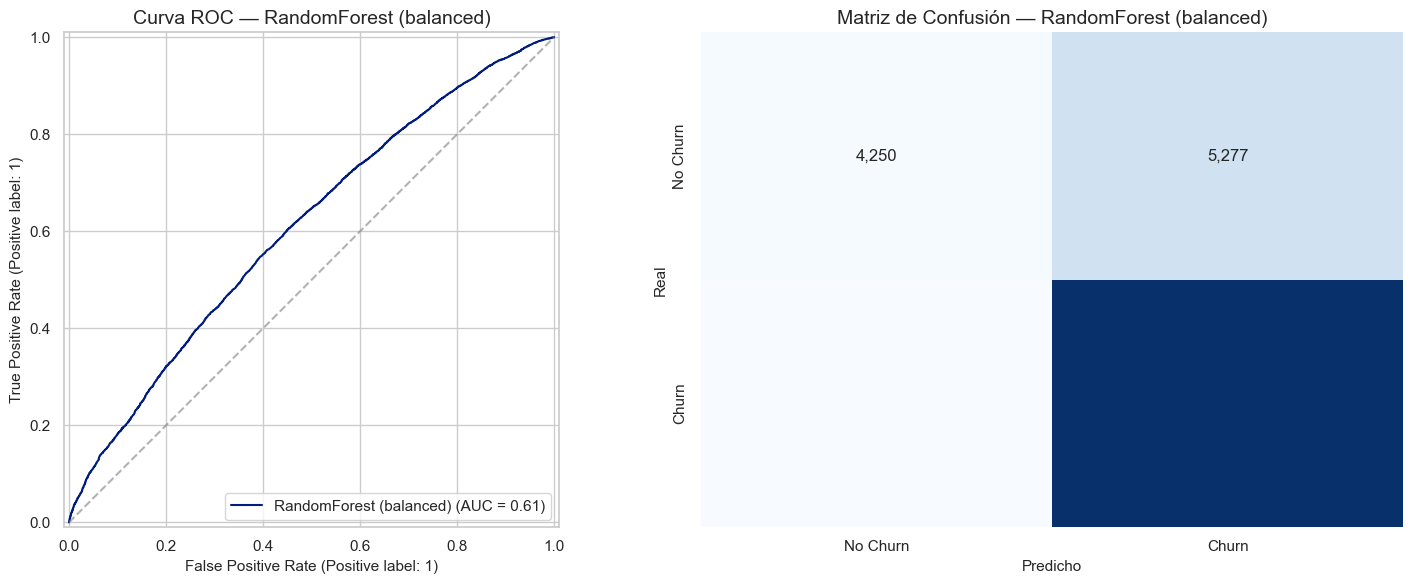


📊 Importancia de variables:
total_orders       0.008
review_score       0.087
gasto_total        0.174
ticket_promedio    0.178
delivery_delay     0.553


In [22]:
# --- Curva ROC + matriz de confusión del mejor modelo por AUC ---
mejor_nombre = tabla['AUC'].idxmax()
mejor_pipe   = modelos[mejor_nombre]
y_pred  = mejor_pipe.predict(X_test)
y_proba = mejor_pipe.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ROC
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0], name=mejor_nombre)
ax[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
ax[0].set_title(f'Curva ROC — {mejor_nombre}')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax[1])
ax[1].set_title(f'Matriz de Confusión — {mejor_nombre}')
ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Real')

plt.tight_layout(); plt.show()

# Importancia de variables (si el modelo la expone)
clf = mejor_pipe.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
    print('\n📊 Importancia de variables:')
    print(imp.round(3).to_string())


In [23]:
# --- Ajuste de umbral de decisión orientado a Recall ---
# En churn, capturar a los que se van (Recall alto) suele importar más que la precisión.
# Bajar el umbral de 0.5 aumenta Recall a costa de más falsos positivos.
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1_por_thr = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
mejor_thr  = thr[f1_por_thr.argmax()]

y_pred_opt = (y_proba >= mejor_thr).astype(int)
print(f'Umbral por defecto : 0.50')
print(f'Umbral óptimo (F1) : {mejor_thr:.2f}')
print(f'\nCon umbral óptimo:')
print(f'  Recall: {recall_score(y_test, y_pred_opt):.3f}')
print(f'  F1    : {f1_score(y_test, y_pred_opt):.3f}')
print(f'  AUC   : {roc_auc_score(y_test, y_proba):.3f}  (no cambia con el umbral)')


Umbral por defecto : 0.50
Umbral óptimo (F1) : 0.32

Con umbral óptimo:
  Recall: 0.988
  F1    : 0.746
  AUC   : 0.607  (no cambia con el umbral)


## 🔭 (Recomendado) Enfoque correcto para evaluación *mensual*: ventana temporal
El enfoque de arriba usa la definición `recencia > 180` excluyendo `recencia` como feature, lo cual evita la fuga pero deja un target débil. El diseño **production-grade** para detectar riesgo de abandono mes a mes es de **ventana de observación + ventana de resultado**:

1. Eliges una fecha de corte `T` (p. ej. fin de cada mes).
2. Construyes las features **solo** con pedidos ocurridos *hasta* `T`.
3. Defines el target mirando *hacia adelante*: `is_churn = 1` si el cliente **no** compró en `(T, T+horizonte]`.

Así el target deja de ser una función de `recencia` y se vuelve un evento futuro real. El esqueleto siguiente queda como guía (requiere repetir el cálculo de RFM con el filtro de fecha):


In [24]:
# ESQUELETO (no ejecutado por defecto): churn con ventana temporal
#
# HORIZONTE = pd.Timedelta(days=180)
# T = df_master['order_purchase_timestamp'].max() - HORIZONTE   # corte de observación
#
# obs = df_master[df_master['order_purchase_timestamp'] <= T]   # features SOLO con esto
# fut = df_master[df_master['order_purchase_timestamp']  > T]   # define el target
#
# clientes_obs = obs['customer_unique_id'].unique()
# recompradores = set(fut['customer_unique_id'])
#
# target = pd.DataFrame({'customer_unique_id': clientes_obs})
# target['is_churn'] = (~target['customer_unique_id'].isin(recompradores)).astype(int)
#
# # -> recalcular total_orders, gasto_total, ticket_promedio, review_score,
# #    delivery_delay USANDO SOLO `obs`, hacer merge con `target`, y entrenar igual
# #    que arriba. La recencia AHORA sí se puede usar como feature (se mide a T,
# #    no define el target).
print('Esqueleto de referencia — descomentar y completar el RFM con filtro <= T.')


Esqueleto de referencia — descomentar y completar el RFM con filtro <= T.
